In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

Data Preprocessing:

In [39]:
data_path = 'AirQuality.csv'
df = pd.read_csv(data_path, delimiter=';')

# Function to convert columns with comma-decimal strings to float
def convert_columns(df, columns):
    for col in columns:
        df[col] = df[col].str.replace(',', '.').astype(float)
    return df

# Specify columns to convert
columns_to_convert = ['CO(GT)', 'C6H6(GT)', 'T', 'RH', 'AH']

# Convert the columns
df = convert_columns(df, columns_to_convert)
# Drop the unnamed columns that are empty
df_cleaned = df.drop(columns=['Unnamed: 15', 'Unnamed: 16'])
df_cleaned.head()




,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


In [40]:
df_cleaned.tail()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
9466,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9467,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9468,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9469,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9470,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [41]:
df_cleaned.describe()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
count,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000
mean,-34.207524,1048.990061,-159.090093,1.865683,894.595276,168.616971,794.990168,58.148873,1391.479641,975.072032,9.778305,39.485380,-6.837604
std,77.657170,329.832710,139.789093,41.380206,342.333252,257.433866,321.993552,126.940455,467.210125,456.938184,43.203623,51.216145,38.976670
min,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000
25%,0.600000,921.000000,-200.000000,4.000000,711.000000,50.000000,637.000000,53.000000,1185.000000,700.000000,10.900000,34.100000,0.692300
50%,1.500000,1053.000000,-200.000000,7.900000,895.000000,141.000000,794.000000,96.000000,1446.000000,942.000000,17.200000,48.600000,0.976800
75%,2.600000,1221.000000,-200.000000,13.600000,1105.000000,284.000000,960.000000,133.000000,1662.000000,1255.000000,24.100000,61.900000,1.296200
max,11.900000,2040.000000,1189.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000


In [42]:
df_cleaned.isnull().sum()

Date             114
Time             114
CO(GT)           114
PT08.S1(CO)      114
NMHC(GT)         114
C6H6(GT)         114
PT08.S2(NMHC)    114
NOx(GT)          114
PT08.S3(NOx)     114
NO2(GT)          114
PT08.S4(NO2)     114
PT08.S5(O3)      114
T                114
RH               114
AH               114
dtype: int64

In [43]:
data=df_cleaned.iloc[:-144]
data.isnull().sum()

Date             0
Time             0
CO(GT)           0
PT08.S1(CO)      0
NMHC(GT)         0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dtype: int64

In [44]:
data =data.copy()
# In data we  lot of -200 which seems to be a error. Removing those values and replacing with Nan i.e null 
data.replace(to_replace= -200, value= pd.NA, inplace= True)
data.isnull().sum()

Date                0
Time                0
CO(GT)           1682
PT08.S1(CO)       366
NMHC(GT)         8413
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
dtype: int64

In [45]:
num_rows = len(data["NMHC(GT)"])
print('Number of rows in NMHC(GT) is :', num_rows) 

Number of rows in NMHC(GT) is : 9327


In [46]:
# 8443 values out of 9327 are -200. This coulmn is not needed thus dropping this coulumn .
data.drop('NMHC(GT)', axis=1, inplace=True)

# Use fillna function to fill the missing values with an estimate value
col_list = data.columns[2:14]

for i in col_list:
    data[i] = data[i].fillna(data[i].mean())

In [47]:
data.isnull().sum()

Date             0
Time             0
CO(GT)           0
PT08.S1(CO)      0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dtype: int64

In [48]:
# Assuming 'df_cleaned' is your DataFrame
data.loc[:, 'Datetime'] = pd.to_datetime(data['Date'] + ' ' + data['Time'], format='%d/%m/%Y %H.%M.%S')

# Now, you can safely drop the 'Date' and 'Time' columns without warnings
data = data.drop(columns=['Date', 'Time'])

# If reordering columns to put 'Datetime' first, ensure to work directly on the DataFrame
columns = ['Datetime'] + [col for col in data.columns if col != 'Datetime']
data = data[columns]
data.head()

,Datetime,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2004-03-10 18:00:00,2.6,1360.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,2004-03-10 19:00:00,2.0,1292.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,2004-03-10 20:00:00,2.2,1402.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,2004-03-10 21:00:00,2.2,1376.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,2004-03-10 22:00:00,1.6,1272.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


In [49]:
data.describe()

,Datetime,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
count,9327,9327.000000,9327.000000,9327.000000,9327.000000,9327.000000,9327.000000,9327.000000,9327.000000,9327.000000,9327.000000,9327.000000,9327.000000
mean,2004-09-21 01:00:00,2.154258,1099.961500,10.093315,939.532865,246.946150,835.712644,113.037476,1457.424729,1023.373507,18.312677,49.283685,1.026705
min,2004-03-10 18:00:00,0.100000,647.000000,0.100000,383.000000,2.000000,322.000000,2.000000,551.000000,221.000000,-1.900000,9.200000,0.184700
25%,2004-06-15 21:30:00,1.200000,941.000000,4.600000,743.000000,112.000000,666.000000,85.500000,1245.000000,742.000000,12.000000,36.600000,0.747150
50%,2004-09-21 01:00:00,2.154258,1075.000000,8.600000,924.000000,229.000000,818.000000,113.037476,1457.424729,983.000000,18.300000,49.283685,1.016600
75%,2004-12-27 04:30:00,2.600000,1222.000000,13.700000,1105.500000,284.000000,961.000000,133.000000,1662.000000,1256.000000,24.100000,61.900000,1.298550
max,2005-04-03 08:00:00,11.900000,2040.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000
std,NaN,1.316554,212.953531,7.306691,261.622990,193.553976,251.926030,43.908647,339.133659,390.564347,8.662444,16.949649,0.395891


Exploratory Data Analysis (EDA):

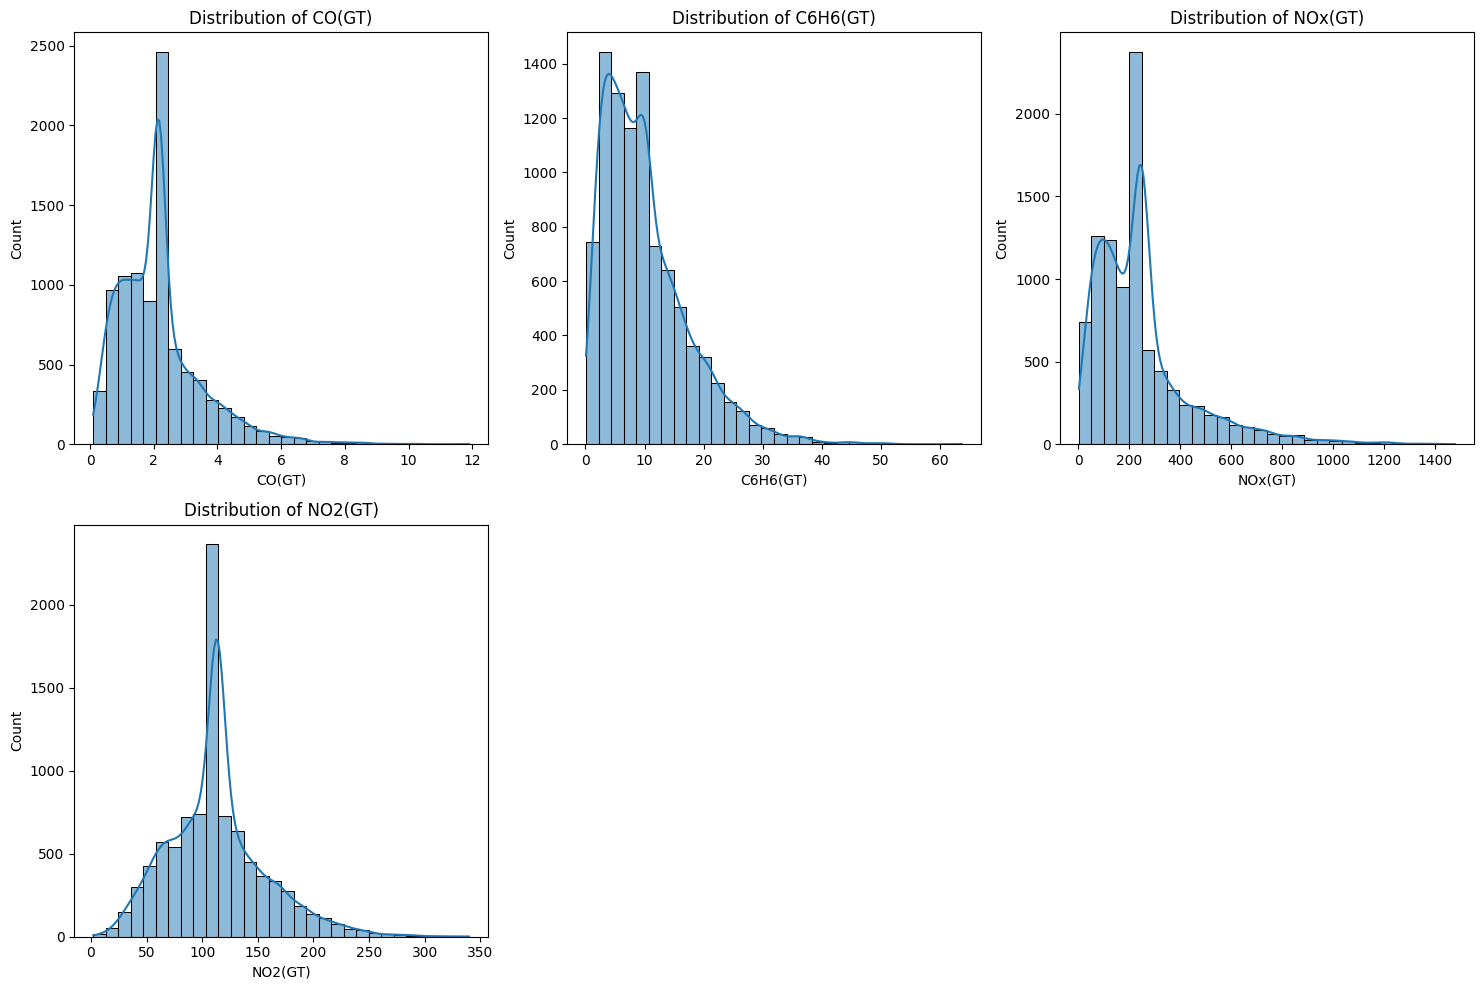

In [50]:
# EDA: Visualize the distribution of air pollutants
pollutants = ['CO(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)']
plt.figure(figsize=(15, 10))
for i, pollutant in enumerate(pollutants, 1):
    plt.subplot(2, 3, i)
    sns.histplot(data[pollutant], kde=True, bins=30)
    plt.title(f'Distribution of {pollutant}')
plt.tight_layout()
plt.show()

Nhìn vào các biểu đồ phân phối cho nồng độ CO (CO(GT)), benzene (C6H6(GT)), oxit nitơ (NOx(GT)), và dioxide nitơ (NO2(GT)), ta có thể nhận xét như sau:

- Phân phối của CO(GT): Biểu đồ cho thấy một phân phối lệch phải với một số giá trị rất cao tạo thành các đuôi dài bên phải, điều này cho thấy một số ngày có nồng độ CO rất cao. Điều này có thể xảy ra do các điều kiện đặc biệt như ô nhiễm không khí nặng hoặc sự cố giao thông.

- Phân phối của C6H6(GT): Tương tự như CO, phân phối của benzene cũng lệch phải. Mặc dù không lệch mạnh như CO nhưng vẫn cho thấy có những ngày nồng độ benzene tăng đáng kể.

- Phân phối của NOx(GT): Phân phối này có dạng tương tự như CO và benzene, với sự lệch phải. Đây là một chỉ báo khác về sự biến động đáng kể trong nồng độ oxit nitơ từ ngày này sang ngày khác.

- Phân phối của NO2(GT): Mặc dù cũng lệch phải nhưng phân phối này ít biên độ hơn so với các chất khác. Điều này có thể cho thấy nồng độ NO2 biến động ít hơn và có thể bị ảnh hưởng bởi những nguồn phát thải địa phương hoặc điều kiện khí tượng cụ thể.

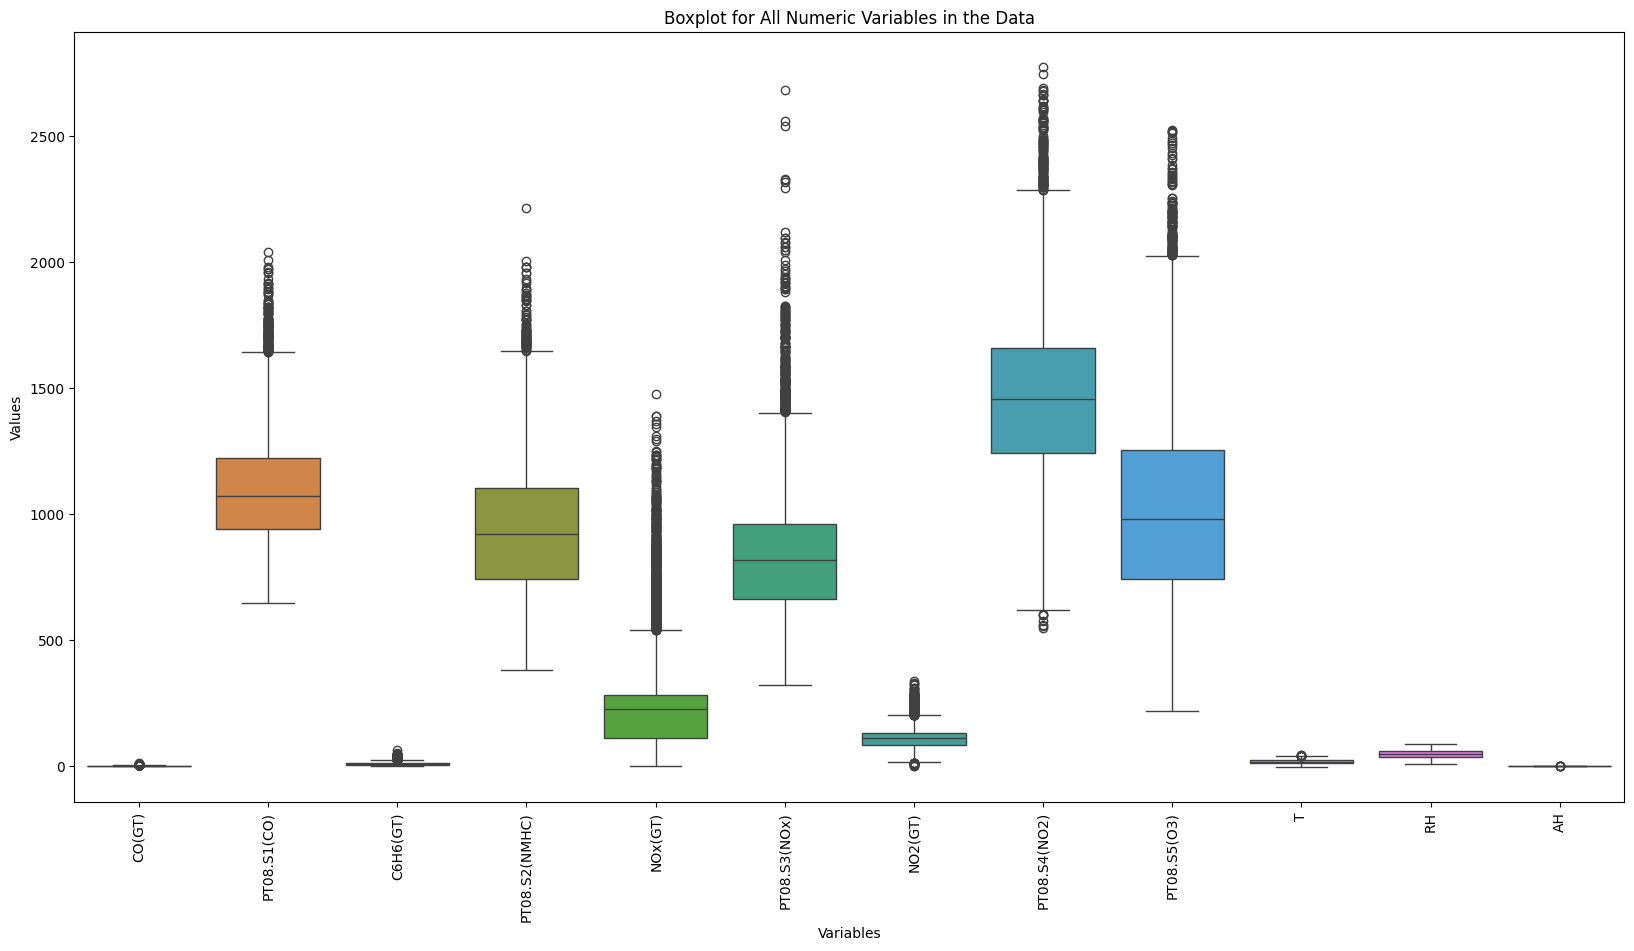

In [52]:
numeric_columns = data.select_dtypes(include=[np.number]).columns.tolist()

plt.figure(figsize=(20, 10))
sns.boxplot(data=data[numeric_columns])
plt.xticks(rotation=90) 
plt.title('Boxplot for All Numeric Variables in the Data')
plt.ylabel('Values')
plt.xlabel('Variables')
plt.show()

The boxplot visualizes the spread and skewness of the distributions for each variable, and it indicates the presence of outliers.

Central Tendency and Spread: The box represents the interquartile range (IQR), with the central line indicating the median. It seems that variables like 'CO(GT)', 'C6H6(GT)', and 'NO2(GT)' have a relatively low median compared to some other variables.

Outliers: Points that are plotted as individual dots are considered outliers. They fall outside 1.5 times the IQR above the upper quartile and below the lower quartile. Variables like 'PT08.S1(CO)', 'NMHC(GT)', and 'NOx(GT)' show a significant number of outliers, suggesting that there are occasional extreme values that could be due to environmental events, sensor malfunctions, or other anomalies.

Skewness: Most of the pollutants have a right-skewed (positive skew) distribution, which indicates that there are a minority of very high values.

Comparisons: 'T', 'RH', and 'AH' have narrower IQRs and fewer outliers, indicating that these environmental variables are less variable than the concentrations of pollutants.

Assessment:

This distribution and outlier information is valuable for data cleaning and preparation for further analysis. For example, outliers may need to be investigated to determine if they should be included in the analysis or if they represent errors.
Depending on the context, if the outliers are legitimate observations, they may represent important extreme pollution events.
The skewness of the distributions suggests that transformations, such as log transformation, might be necessary for any parametric statistical analyses to meet the assumptions of normality.
Remarks:

For 'NMHC(GT)', there is a high number of outliers, which is a bit unusual and should be checked for data accuracy.
Environmental factors like 'T', 'RH', and 'AH' are less prone to extreme outliers, which is expected since these factors usually have natural bounds and less day-to-day variation.

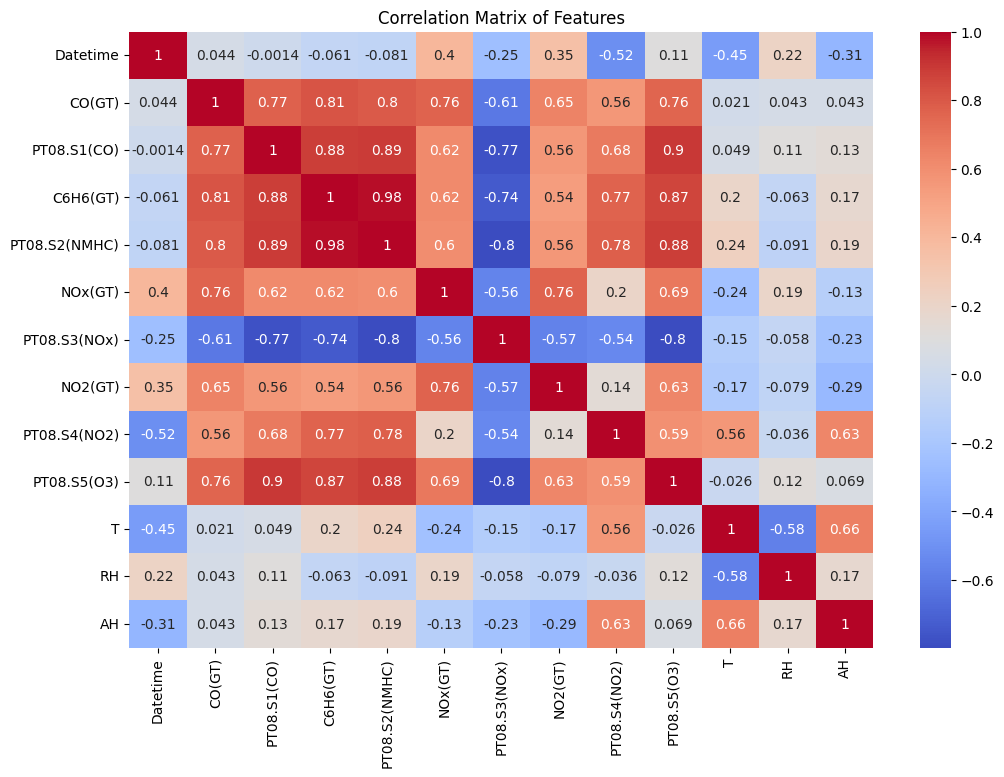

In [ ]:
# Correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Features')
plt.show()

Đánh Giá Ma Trận Tương Quan Của Các Đặc Trưng
- Giá trị tương quan dao động từ -1 đến 1, với -1 chỉ ra mối quan hệ tương quan âm mạnh mẽ, 0 không có tương quan, và 1 chỉ ra mối quan hệ tương quan dương mạnh mẽ.

Quan sát từ ma trận tương quan:
- Các đặc trưng CO(GT), PT08.S1(CO), C6H6(GT), PT08.S2(NMHC), NOx(GT), NO2(GT), và PT08.S4(NO2) có tương quan dương mạnh với nhau, điều này có thể cho thấy sự phụ thuộc lẫn nhau giữa nồng độ các chất ô nhiễm.
- Đặc biệt, C6H6(GT) và PT08.S2(NMHC) có tương quan gần như hoàn hảo (0.98), có thể ngụ ý rằng một trong hai đặc trưng này không cần thiết cho việc mô hình hóa do mang thông tin gần như giống hệt nhau.
- Các đặc trưng như nhiệt độ (T) và độ ẩm tương đối (RH) có tương quan Yếu với các chất ô nhiễm, điều này chỉ ra rằng chúng có thể không là những yếu tố quan trọng trong việc dự đoán nồng độ các chất ô nhiễm.

Ý Nghĩa Và Ảnh Hưởng Trong Mô Hình Hóa
- Mức độ cao của tương quan giữa các chất ô nhiễm có thể gây ra vấn đề Đa Cộng Tuyến khi sử dụng các mô hình hồi quy. Điều này đòi hỏi cần thận trọng khi lựa chọn đặc trưng cho mô hình.
- Tương quan yếu giữa T, RH và các chất ô nhiễm khác có thể giúp mô hình hiểu rõ hơn về các hiện tượng độc lập với điều kiện khí hậu.

Kết Luận
- Phân tích ma trận tương quan cho thấy cần có sự cân nhắc khi chọn lọc các đặc trưng cho mô hình học máy. Có khả năng cần phải loại bỏ một số đặc trưng để giảm thiểu đa cộng tuyến và cải thiện khả năng tổng quát hóa của mô hình.

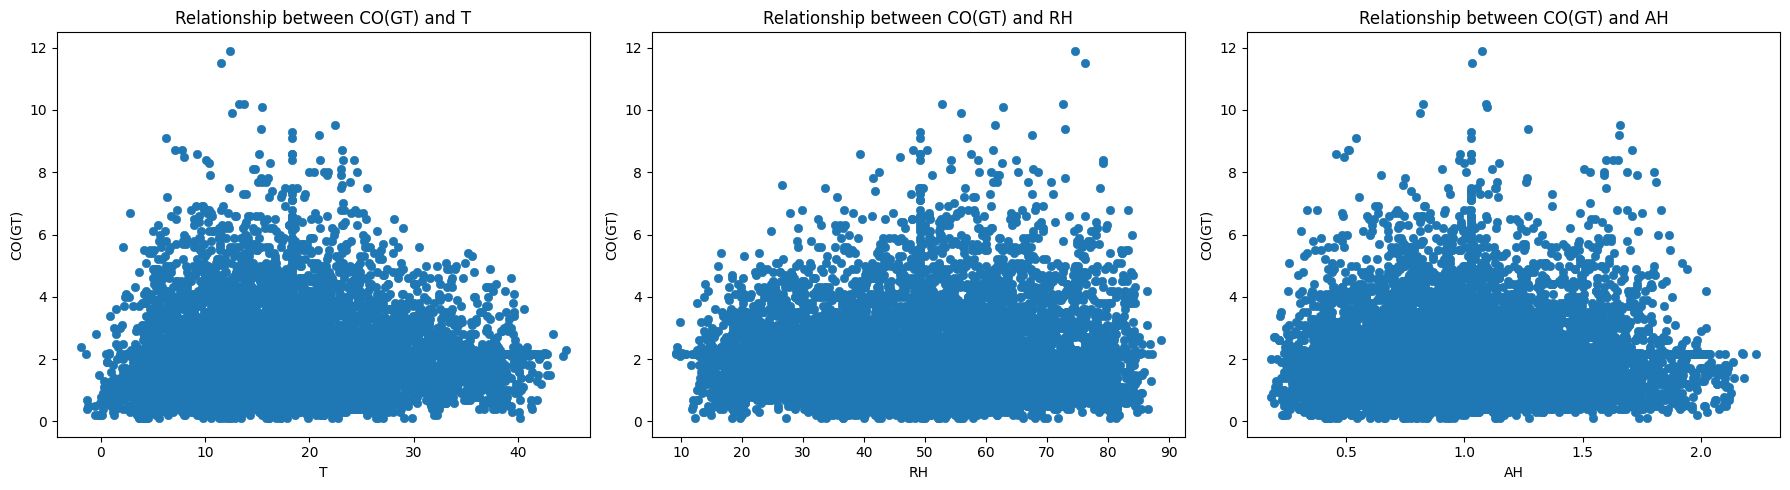

In [53]:
pollutant = 'CO(GT)'
air_quality_data = data[data[pollutant] > 0]
factors = ['T', 'RH', 'AH']

def plot_pollutant_relationships_v2(data, pollutant, factors):
    plt.figure(figsize=(18, 5))
    
    for i, factor in enumerate(factors, 1):
        plt.subplot(1, len(factors), i)
        sns.scatterplot(x=factor, y=pollutant, data=data, edgecolor=None)
        plt.title(f'Relationship between {pollutant} and {factor}')
        plt.xlabel(factor)
        plt.ylabel(pollutant)
    
    plt.tight_layout()
    plt.show()

# Create scatter plots with the updated aesthetics
plot_pollutant_relationships_v2(air_quality_data, pollutant, factors)


Biểu đồ phân tán này cho thấy mối quan hệ giữa nồng độ CO (một chỉ số chất lượng không khí) và ba yếu tố môi trường: nhiệt độ (T), độ ẩm tương đối (RH), và độ ẩm tuyệt đối (AH).

Mối quan hệ giữa CO và Nhiệt độ (T): Có vẻ như khi nhiệt độ tăng, nồng độ CO giảm nhẹ, đặc biệt là ở nhiệt độ thấp hơn. Điều này có thể phản ánh sự thực là nhiệt độ cao hơn thường liên quan đến tốc độ phản ứng hóa học cao hơn trong không khí, có thể làm giảm nồng độ CO.

Mối quan hệ giữa CO và Độ ẩm tương đối (RH): Dữ liệu cho thấy sự phân bố rộng và không có một xu hướng rõ ràng nào giữa độ ẩm tương đối và nồng độ CO.

Mối quan hệ giữa CO và Độ ẩm tuyệt đối (AH): Có vẻ như có một xu hướng tăng nồng độ CO với độ ẩm tuyệt đối thấp. Khi độ ẩm tuyệt đối tăng, nồng độ CO lại có xu hướng giảm.

Nhận xét:

Cần lưu ý rằng các mối quan hệ này có thể không chỉ là tuyến tính và có thể bị ảnh hưởng bởi các yếu tố khác như nguồn phát thải, điều kiện khí tượng, và hoạt động con người.
Mối quan hệ giữa CO và các yếu tố môi trường cần được nghiên cứu thêm thông qua phân tích thống kê chặt chẽ và mô hình hóa.
Các điểm dữ liệu nằm xa các cụm chính có thể là các ngoại lệ hoặc có thể đại diện cho các sự kiện ô nhiễm cực đoan cần được xem xét kỹ lưỡng.
Những biểu đồ như thế này hữu ích trong việc định hình những giả thuyết ban đầu cho các nghiên cứu sâu hơn về ảnh hưởng của điều kiện môi trường đến chất lượng không khí.

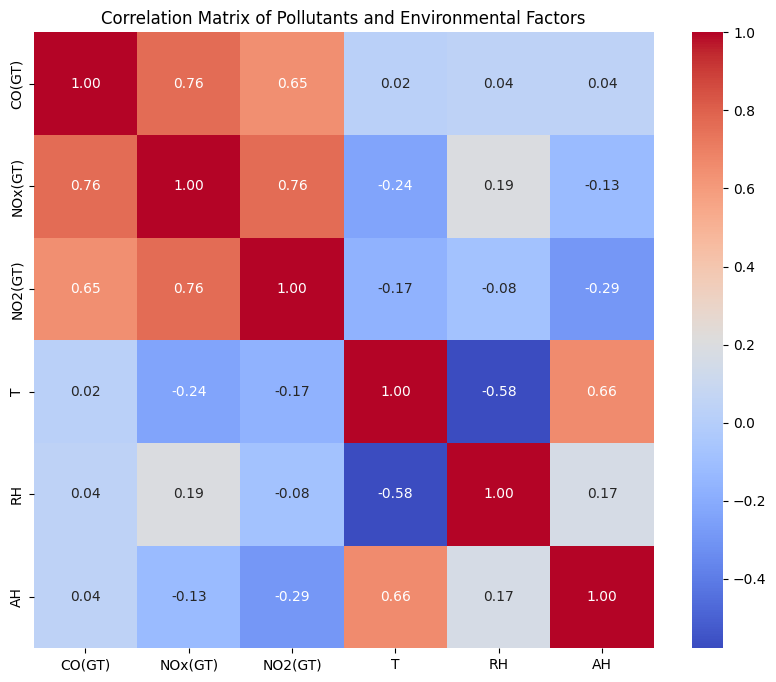

In [54]:
pollutants = ['CO(GT)', 'NOx(GT)', 'NO2(GT)']  # Example pollutants, these should be adjusted based on actual data columns
factors = ['T', 'RH', 'AH']
correlation_columns = pollutants + factors

# Calculate the correlation matrix for the selected columns
correlation_matrix = data[correlation_columns].corr()

# Visualizing the correlation matrix using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix of Pollutants and Environmental Factors')
plt.show()


ChatGPT
Biểu đồ ma trận tương quan bạn cung cấp hiển thị mức độ tương quan giữa các chỉ số ô nhiễm không khí và các yếu tố môi trường như nhiệt độ (T), độ ẩm tương đối (RH), và độ ẩm tuyệt đối (AH). Màu sắc càng gần đỏ cho thấy mối tương quan dương, trong khi màu xanh cho thấy tương quan âm.

Dựa trên biểu đồ này, có thể nhận xét như sau:

Các chỉ số ô nhiễm không khí CO(GT), NOx(GT), và NO2(GT) có mối tương quan cao với nhau (màu đỏ sậm), cho thấy khi một trong những chỉ số này tăng thì các chỉ số còn lại cũng có xu hướng tăng.

Nhiệt độ (T) có mối tương quan âm với độ ẩm tương đối (RH), tức là khi nhiệt độ cao thì độ ẩm có xu hướng giảm. Đồng thời, nhiệt độ có tương quan dương với độ ẩm tuyệt đối (AH), điều này phản ánh sự thực tế là không khí ấm có thể chứa nhiều hơi nước hơn.

Độ ẩm tuyệt đối (AH) có một mức độ tương quan nhẹ với nhiệt độ (T) và không có mối tương quan rõ rệt với độ ẩm tương đối (RH), điều này cũng phản ánh mối liên hệ phức tạp giữa nhiệt độ, độ ẩm, và lượng hơi nước mà không khí có thể giữ được.

Không có mối tương quan rõ rệt nào được phát hiện giữa các chỉ số ô nhiễm không khí và nhiệt độ hoặc độ ẩm, điều này có thể báo hiệu rằng mặc dù các yếu tố môi trường có ảnh hưởng đến mức độ ô nhiễm, nhưng mối quan hệ này không phải là tuyến tính đơn giản và có thể bị ảnh hưởng bởi nhiều yếu tố khác.

Nhận xét tổng quan:

Biểu đồ này cung cấp cái nhìn tổng quan về mối tương quan giữa các biến số và có thể được sử dụng làm cơ sở để điều tra sâu hơn về các mối quan hệ nguyên nhân hoặc để phát triển mô hình dự báo ô nhiễm không khí. Mối tương quan không chứng minh mối quan hệ nguyên nhân, nhưng nó là một điểm khởi đầu hữu ích để phân tích tiếp theo.

Data Splitting:

In [ ]:
timesteps = 3
features = data.drop(['CO(GT)', 'Datetime'], axis=1)
features_timesteps = np.array([features.iloc[i:i+timesteps].values.flatten() for i in range(len(features) - timesteps + 1)])
target_timesteps = data['CO(GT)'].iloc[timesteps - 1:].values

X_train_ts, X_test_ts, y_train_ts, y_test_ts = train_test_split(features_timesteps, target_timesteps, test_size=0.3, shuffle=False)

Model RF Building:

In [ ]:
rf_model_ts = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model_ts.fit(X_train_ts, y_train_ts)
y_pred_rf_ts = rf_model_ts.predict(X_test_ts)

rmse_rf_ts = np.sqrt(mean_squared_error(y_test_ts, y_pred_rf_ts))
r2_rf_ts = r2_score(y_test_ts, y_pred_rf_ts)
rmse_rf_ts, r2_rf_ts

(0.7897068616828589, 0.6934655294148326)

Model KNN Building :

In [ ]:
scaler_ts = MinMaxScaler()
X_train_ts_scaled = scaler_ts.fit_transform(X_train_ts)
X_test_ts_scaled = scaler_ts.transform(X_test_ts)

knn_model_ts = KNeighborsRegressor(n_neighbors=5)
knn_model_ts.fit(X_train_ts_scaled, y_train_ts)
y_pred_knn_ts = knn_model_ts.predict(X_test_ts_scaled)

rmse_knn_ts = np.sqrt(mean_squared_error(y_test_ts, y_pred_knn_ts))
r2_knn_ts = r2_score(y_test_ts, y_pred_knn_ts)
rmse_knn_ts, r2_knn_ts

(0.877980443852308, 0.621106477204792)

Model Evaluation:

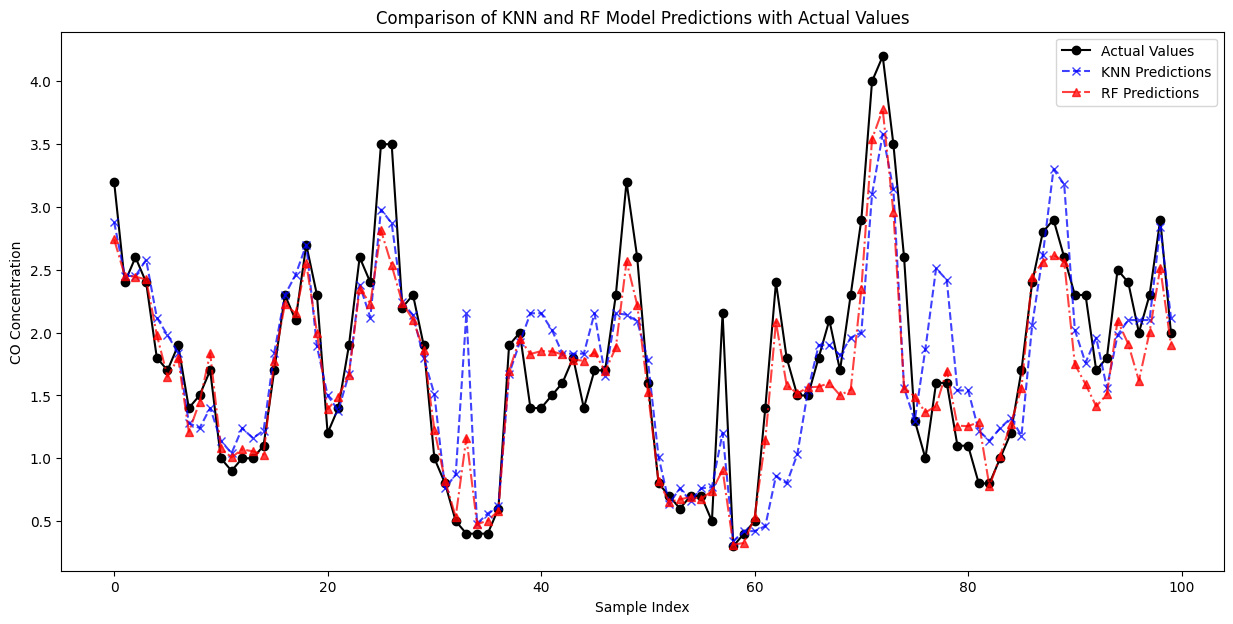

In [ ]:


# Chọn số lượng mẫu để trực quan hóa
sample_size = 100
index = np.arange(0, sample_size)

# Trực quan hóa dự đoán của mô hình KNN và RF cùng với giá trị thực tế
plt.figure(figsize=(15, 7))
plt.plot(index, y_test_ts[:sample_size], label='Actual Values', marker='o', color='black')
plt.plot(index, y_pred_knn_ts[:sample_size], label='KNN Predictions', alpha=0.75, marker='x', linestyle='--', color='blue')
plt.plot(index, y_pred_rf_ts[:sample_size], label='RF Predictions', alpha=0.75, marker='^', linestyle='-.', color='red')

plt.title('Comparison of KNN and RF Model Predictions with Actual Values')
plt.xlabel('Sample Index')
plt.ylabel('CO Concentration')
plt.legend()
plt.show()


Đánh Giá Kết Quả Từ Các Mô Hình
   - Sau khi áp dụng hai mô hình học máy là RandomForestRegressor và KNeighborsRegressor để dự đoán nồng độ CO dựa trên các đặc trưng khác nhau của dữ liệu chất lượng không khí, chúng ta tiến hành đánh giá hiệu suất của chúng qua các chỉ số RMSE (Root Mean Square Error) và R^2 (R-squared).

So Sánh Hiệu Suất Mô Hình

- Random Forest Regressor:
  - RMSE: 0.7897
  - R^2: 0.6934
- KNeighbors Regressor:
  - RMSE: 0.87798
  - R^2: 0.6211

RMSE cung cấp một ước lượng về sai số trung bình giữa các giá trị dự đoán và thực tế, trong khi R^2 đo lường tỷ lệ phương sai được giải thích bởi mô hình. Một giá trị R^2 cao và một giá trị RMSE thấp cho thấy mô hình dự đoán chính xác hơn.

Đánh Giá Biểu Đồ So Sánh Dự Đoán và Giá Trị Thực Tế

Biểu đồ trên thể hiện sự so sánh giữa giá trị dự đoán từ mô hình KNeighborsRegressor và RandomForestRegressor so với giá trị thực tế. Qua đó, ta có thể thấy rằng mô hình RandomForestRegressor có xu hướng dự đoán chính xác hơn so với mô hình KNeighborsRegressor, như được thể hiện qua sự gần gũi của đường dự đoán với giá trị thực tế. Dù cả hai mô hình đều phản ánh xu hướng chung của dữ liệu, RandomForestRegressor ít biến động và gần với giá trị thực tế hơn so với KNeighborsRegressor, đặc biệt là ở những điểm có sự thay đổi lớn về nồng độ CO.
- Kết Luận
  - Dựa trên kết quả đánh giá, RandomForestRegressor cho thấy hiệu suất tốt hơn KNeighborsRegressor trong việc dự đoán nồng độ CO dựa trên dữ liệu này. Điều này được chứng minh bởi giá trị RMSE thấp và giá trị R^2 cao hơn của mô hình RandomForestRegressor so với KNeighborsRegressor.

Để cải thiện thêm hiệu suất mô hình, có thể xem xét việc tinh chỉnh các tham số mô hình, sử dụng kỹ thuật chọn lọc đặc trưng, hoặc áp dụng các phương pháp xử lý dữ liệu tiên tiến hơn.
